# Long-Term PV Evolution Demo

This notebook demonstrates production-grade long-term PV analysis.

Goal:
- Fit a single-variable linear model between `solar_radiation` and `electricity_produced` on the first 12 months.
- Evaluate subsequent calendar years.
- Report yearly actual vs predicted production and error metrics.
- Include regression diagnostics (coefficient, intercept, R-squared).

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from openenergyid.pv_evolution import LongTermPVAnalyzer, PVLongTermAnalysisInput

## 1. Load Typed Input Sample

We use a prebuilt `PVLongTermAnalysisInput` JSON sample:
- path: `data/pv_analysis/pv_long_term_analysis_input.json`
- includes daily (`P1D`) time series data in `index`, `columns`, and `data`
- includes metadata (`timeZone`, optional `reference`, optional `baselineStart` / `baselineEnd`)


In [2]:
raw_input = Path("data/pv_analysis/pv_long_term_analysis_input.json").read_text(encoding="utf-8")
analysis_input = PVLongTermAnalysisInput.model_validate_json(raw_input)

In [3]:
input_df = analysis_input.to_pandas(timezone=analysis_input.timezone)
input_df.head()

,solar_radiation,electricity_produced
2021-11-01 00:00:00+01:00,796.67,186.311
2021-11-02 00:00:00+01:00,796.67,126.762
2021-11-03 00:00:00+01:00,796.67,168.541
2021-11-04 00:00:00+01:00,796.67,137.865
2021-11-05 00:00:00+01:00,796.67,175.500


## 2. Run Long-Term Analysis

The analyzer fits a month-like reference model on balanced baseline buckets built from daily data and evaluates each calendar year on true calendar months (`MS`).


In [4]:
analyzer = LongTermPVAnalyzer()
analysis_output = analyzer.analyze(analysis_input)
analysis_output

PVLongTermAnalysisOutput(reference='sample-pv-site', baseline_period=PVBaselinePeriod(start=datetime.date(2021, 11, 1), end=datetime.date(2022, 10, 31)), yearly_results=[PVYearResult(year=2022, actual_production=141568.14, predicted_production=141733.05868881772, error=-164.91868881770642, relative_error=-0.0011649421177512569, complete_year=True), PVYearResult(year=2023, actual_production=123519.909, predicted_production=128255.14676632018, error=-4735.237766320177, relative_error=-0.03833582622150553, complete_year=True), PVYearResult(year=2024, actual_production=109272.23599999999, predicted_production=115978.33965876377, error=-6706.103658763779, relative_error=-0.06137060889614979, complete_year=True), PVYearResult(year=2025, actual_production=126849.63600000001, predicted_production=149799.61906014947, error=-22949.98306014946, relative_error=-0.18092273485238428, complete_year=True), PVYearResult(year=2026, actual_production=16791.368000000002, predicted_production=20495.0167888

## 3. Inspect Regression Diagnostics

In [5]:
diagnostics_df = pd.DataFrame(
    [
        {
            "coefficient": analysis_output.regression_diagnostics.coefficient,
            "intercept": analysis_output.regression_diagnostics.intercept,
            "r_squared": analysis_output.regression_diagnostics.r_squared,
        }
    ]
)

diagnostics_df

,coefficient,intercept,r_squared
0,0.126434,0.0,0.997447


## 4. Review Per-Year Results

In [6]:
yearly_df = pd.DataFrame(
    [
        {
            "year": row.year,
            "actual_production": row.actual_production,
            "predicted_production": row.predicted_production,
            "error": row.error,
            "relative_error_pct": row.relative_error * 100
            if row.relative_error is not None
            else None,
            "complete_year": row.complete_year,
        }
        for row in analysis_output.yearly_results
    ]
)

yearly_df

,year,actual_production,predicted_production,error,relative_error_pct,complete_year
0,2022,141568.140,141733.058689,-164.918689,-0.116494,True
1,2023,123519.909,128255.146766,-4735.237766,-3.833583,True
2,2024,109272.236,115978.339659,-6706.103659,-6.137061,True
3,2025,126849.636,149799.619060,-22949.983060,-18.092273,True
4,2026,16791.368,20495.016789,-3703.648789,-22.056862,False


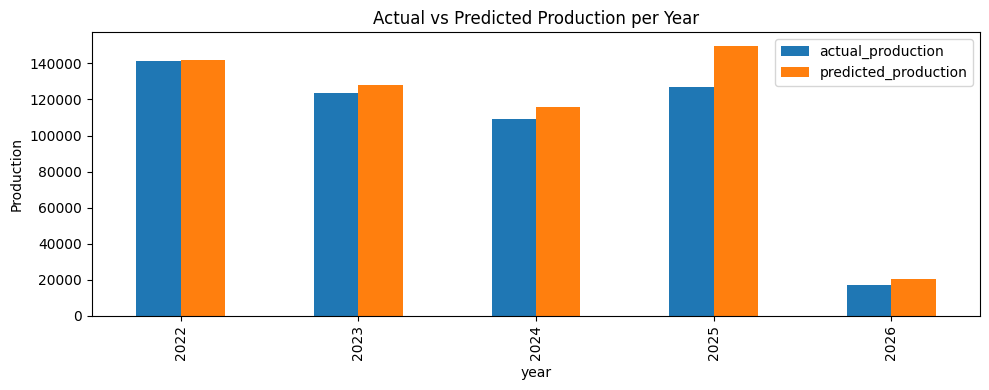

In [7]:
ax = yearly_df.plot(
    x="year",
    y=["actual_production", "predicted_production"],
    kind="bar",
    figsize=(10, 4),
)
ax.set_ylabel("Production")
ax.set_title("Actual vs Predicted Production per Year")
plt.tight_layout()
plt.show()

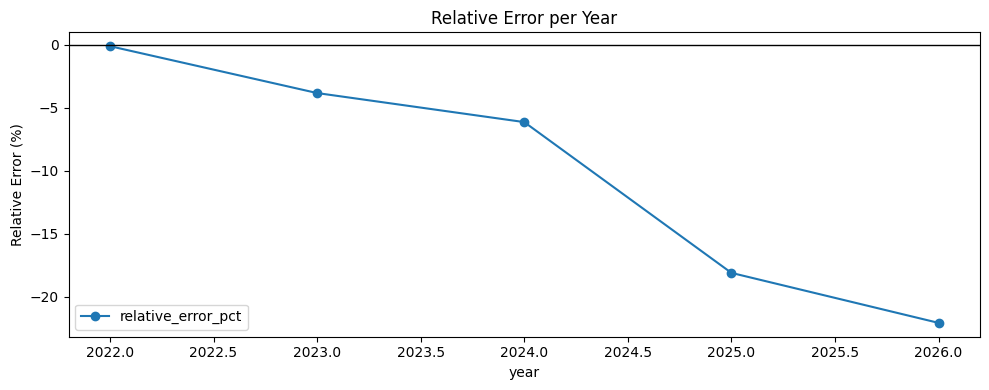

In [8]:
ax = yearly_df.plot(
    x="year",
    y="relative_error_pct",
    marker="o",
    figsize=(10, 4),
)
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Relative Error (%)")
ax.set_title("Relative Error per Year")
plt.tight_layout()
plt.show()

## 5. Serialize Typed Output

`PVLongTermAnalysisOutput` is JSON-ready and supports API aliases.

In [9]:
print(analysis_output.model_dump_json(by_alias=True, indent=2))

{
  "reference": "sample-pv-site",
  "baselinePeriod": {
    "start": "2021-11-01",
    "end": "2022-10-31"
  },
  "yearlyResults": [
    {
      "year": 2022,
      "actualProduction": 141568.14,
      "predictedProduction": 141733.05868881772,
      "error": -164.91868881770642,
      "relativeError": -0.0011649421177512569,
      "completeYear": true
    },
    {
      "year": 2023,
      "actualProduction": 123519.909,
      "predictedProduction": 128255.14676632018,
      "error": -4735.237766320177,
      "relativeError": -0.03833582622150553,
      "completeYear": true
    },
    {
      "year": 2024,
      "actualProduction": 109272.23599999999,
      "predictedProduction": 115978.33965876377,
      "error": -6706.103658763779,
      "relativeError": -0.06137060889614979,
      "completeYear": true
    },
    {
      "year": 2025,
      "actualProduction": 126849.63600000001,
      "predictedProduction": 149799.61906014947,
      "error": -22949.98306014946,
      "relativeErro